## Regression Pipeline
Load data, preprocess, train, evaluate, and create submission.

In [ ]:
import pandas as pd
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import KFold, cross_val_score
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)

## Load Datasets
Read train, test, and sample submission files.

In [35]:
test_df = pd.read_csv("./data/test.csv")
df = pd.read_csv("./data/train.csv")
sample = pd.read_csv("./data/sample_submission.csv")

## Initial Check
Quick look at raw training rows.

In [36]:
df.head()

,id,emotional_charge_2,groove_efficiency_1,beat_frequency_1,organic_texture_2,composition_label_0,harmonic_scale_1,intensity_index_0,duration_ms_0,album_name_length,beat_frequency_0,beat_frequency_2,artist_count,composition_label_1,publication_timestamp,weekday_of_release,album_component_count,emotional_charge_1,emotional_charge_0,tonal_mode_2,key_variety,performance_authenticity_2,performance_authenticity_0,season_of_release,time_signature_1,duration_ms_2,lunar_phase,instrumental_density_2,organic_texture_0,creator_collective,vocal_presence_2,tonal_mode_1,vocal_presence_1,vocal_presence_0,intensity_index_1,organic_immersion_0,tonal_mode_0,groove_efficiency_2,instrumental_density_1,organic_immersion_2,duration_consistency,composition_label_2,organic_texture_1,rhythmic_cohesion_0,track_identifier,emotional_resonance_1,rhythmic_cohesion_1,performance_authenticity_1,tempo_volatility,organic_immersion_1,groove_efficiency_0,emotional_resonance_2,time_signature_0,duration_ms_1,harmonic_scale_0,time_signature_2,rhythmic_cohesion_2,emotional_resonance_0,harmonic_scale_2,intensity_index_2,instrumental_density_0,target
0,76339,0.482850,1.169231,80.018,0.0201,Country Stuff (feat. Jake Owen),1.0,0.789,154586.0,NaN,95.992,162.045,NaN,Fancy Like,2021-06-04,Friday,6.0,0.640680,0.478923,1.0,2.0,0.1120,0.336,summer,4.0,189853.0,waning,0.000000,0.09900,"Walker Hayes,",0.0322,1.0,0.0574,0.1420,NaN,0.255067,1.0,NaN,0.000000,0.063601,15204.423983,NaN,0.1140,0.685,NaN,0.843,0.649,0.3170,82.027,0.307521,1.150146,0.666,4.0,161853.0,7.0,4.0,NaN,0.607,7.0,0.7250,0.000000,74
1,80006,0.267862,1.321321,147.966,0.3340,Solitude,6.0,0.715,46874.0,15.0,148.076,125.964,2.0,TryHard,2019-07-01,Monday,3.0,0.255200,0.559845,0.0,3.0,0.1720,0.752,summer,4.0,123272.0,waning,0.000083,0.00758,"Zpvrt,",NaN,0.0,0.7210,0.4760,0.880,NaN,1.0,0.879147,0.000000,0.686214,45592.954911,WontYouSaveMe,0.1310,0.523,BornTo DieAlone,0.290,0.665,0.0825,22.112,0.339768,NaN,0.361,4.0,155619.0,1.0,4.0,0.843,0.783,4.0,NaN,0.043200,2
2,83501,0.242606,1.285319,142.980,0.1110,BDFFRNT (Saved from Conformity),4.0,NaN,264665.0,7.0,124.738,134.403,2.0,Wow,2014-11-18,NaN,14.0,0.456576,0.148544,0.0,3.0,0.0828,0.189,autumn,4.0,302686.0,full,0.000000,0.44500,"Dillon Chase,",0.3280,0.0,0.4030,0.2890,0.928,1.962932,0.0,0.912121,0.000000,0.559969,38309.603777,NaN,0.0179,NaN,BDFFRNT,0.492,0.721,0.3970,18.242,0.062464,1.270758,0.403,4.0,209378.0,6.0,4.0,NaN,0.211,10.0,0.6020,0.000000,35
3,81530,0.426400,1.279435,123.063,0.1960,Headlights (feat. Ilsey),5.0,0.685,209208.0,5.0,NaN,107.936,2.0,Sugar (feat. Francesco Yates),2015-09-25,Friday,15.0,0.518340,0.252765,0.0,3.0,0.1560,0.182,autumn,4.0,187126.0,full,0.000000,0.02450,NaN,0.0630,0.0,0.0581,0.0367,0.815,0.085427,1.0,1.166430,0.000000,0.611278,13345.980827,Heatwave (feat. Akon),0.0185,0.597,Sugar,0.636,0.636,0.1630,NaN,0.067538,1.145485,0.520,4.0,219043.0,11.0,4.0,0.702,0.369,NaN,0.8200,0.000335,70
4,60534,0.000000,0.974906,132.722,0.0811,Afraid,6.0,0.856,215346.0,5.0,118.006,0.000,2.0,Maneater,2006-01-01,NaN,17.0,0.611499,0.540136,1.0,2.0,0.0000,0.697,winter,4.0,6413.0,waxing,0.000000,0.11300,"Nelly Furtado,",0.0000,1.0,0.0397,0.0430,0.777,0.405568,0.0,NaN,0.000358,0.008668,110199.561452,Promiscuous Interlude,0.0261,0.760,Loose,0.787,0.796,0.1210,132.722,0.112618,1.124836,0.000,4.0,258893.0,1.0,0.0,0.000,0.631,1.0,0.0221,0.000000,78


## Preprocess Train
Drop unused columns, handle missing values, and encode features.

In [37]:
df = df.drop(['composition_label_0', 'composition_label_1', 'creator_collective', 'composition_label_2', 'track_identifier'], axis=1)

In [38]:
df = df.dropna(subset = ['weekday_of_release', 'season_of_release', 'lunar_phase'])

In [39]:
df = df.fillna(0)

In [40]:
week = pd.get_dummies(df['weekday_of_release'], prefix='weekday', dtype=int)
df = df.drop('weekday_of_release',axis = 1)
df = df.join(week)

season = pd.get_dummies(df['season_of_release'], prefix='season', dtype=int)
df = df.drop('season_of_release',axis = 1)
df = df.join(season)

lunar = pd.get_dummies(df['lunar_phase'], prefix='lunar', dtype=int)
df = df.drop('lunar_phase',axis = 1)
df = df.join(lunar)

In [41]:
df['publication_timestamp'] = pd.to_datetime(
    df['publication_timestamp'],
    errors='coerce'
)

df['year'] = df['publication_timestamp'].dt.year
df['month'] = df['publication_timestamp'].dt.month
df['day'] = df['publication_timestamp'].dt.day
df = df.drop('publication_timestamp', axis=1)

In [42]:
df.head()

,id,emotional_charge_2,groove_efficiency_1,beat_frequency_1,organic_texture_2,harmonic_scale_1,intensity_index_0,duration_ms_0,album_name_length,beat_frequency_0,beat_frequency_2,artist_count,album_component_count,emotional_charge_1,emotional_charge_0,tonal_mode_2,key_variety,performance_authenticity_2,performance_authenticity_0,time_signature_1,duration_ms_2,instrumental_density_2,organic_texture_0,vocal_presence_2,tonal_mode_1,vocal_presence_1,vocal_presence_0,intensity_index_1,organic_immersion_0,tonal_mode_0,groove_efficiency_2,instrumental_density_1,organic_immersion_2,duration_consistency,organic_texture_1,rhythmic_cohesion_0,emotional_resonance_1,rhythmic_cohesion_1,performance_authenticity_1,tempo_volatility,organic_immersion_1,groove_efficiency_0,emotional_resonance_2,time_signature_0,duration_ms_1,harmonic_scale_0,time_signature_2,rhythmic_cohesion_2,emotional_resonance_0,harmonic_scale_2,intensity_index_2,instrumental_density_0,target,weekday_Friday,weekday_Monday,weekday_Saturday,weekday_Sunday,weekday_Thursday,weekday_Tuesday,weekday_Wednesday,season_autumn,season_spring,season_summer,season_winter,lunar_full,lunar_new,lunar_waning,lunar_waxing,year,month,day
0,76339,0.482850,1.169231,80.018,0.0201,1.0,0.789,154586.0,0.0,95.992,162.045,0.0,6.0,0.640680,0.478923,1.0,2.0,0.112,0.3360,4.0,189853.0,0.000000,0.09900,0.0322,1.0,0.0574,0.1420,0.000,0.255067,1.0,0.000000,0.000000,0.063601,15204.423983,0.11400,0.685,0.843,0.649,0.3170,82.027,0.307521,1.150146,0.666,4.0,161853.0,7.0,4.0,0.000,0.607,7.0,0.725,0.000000,74,1,0,0,0,0,0,0,0,0,1,0,0,0,1,0,2021.0,6.0,4.0
1,80006,0.267862,1.321321,147.966,0.3340,6.0,0.715,46874.0,15.0,148.076,125.964,2.0,3.0,0.255200,0.559845,0.0,3.0,0.172,0.7520,4.0,123272.0,0.000083,0.00758,0.0000,0.0,0.7210,0.4760,0.880,0.000000,1.0,0.879147,0.000000,0.686214,45592.954911,0.13100,0.523,0.290,0.665,0.0825,22.112,0.339768,0.000000,0.361,4.0,155619.0,1.0,4.0,0.843,0.783,4.0,0.000,0.043200,2,0,1,0,0,0,0,0,0,0,1,0,0,0,1,0,2019.0,7.0,1.0
3,81530,0.426400,1.279435,123.063,0.1960,5.0,0.685,209208.0,5.0,0.000,107.936,2.0,15.0,0.518340,0.252765,0.0,3.0,0.156,0.1820,4.0,187126.0,0.000000,0.02450,0.0630,0.0,0.0581,0.0367,0.815,0.085427,1.0,1.166430,0.000000,0.611278,13345.980827,0.01850,0.597,0.636,0.636,0.1630,0.000,0.067538,1.145485,0.520,4.0,219043.0,11.0,4.0,0.702,0.369,0.0,0.820,0.000335,70,1,0,0,0,0,0,0,1,0,0,0,1,0,0,0,2015.0,9.0,25.0
5,69293,0.378675,1.396825,119.998,0.0541,3.0,0.912,199434.0,6.0,114.993,119.984,2.0,11.0,0.523600,0.675792,1.0,3.0,0.110,0.1090,4.0,202988.0,0.000000,0.00780,0.0453,1.0,0.0396,0.0521,0.880,0.025926,1.0,1.558333,0.000427,0.000000,4305.448435,0.00124,0.699,0.595,0.629,0.1370,0.000,0.004336,1.302857,0.405,4.0,209810.0,4.0,4.0,0.599,0.741,10.0,0.935,0.000000,44,0,0,0,1,0,0,0,0,0,1,0,1,0,0,0,2014.0,8.0,17.0
6,27190,0.719572,1.484034,89.991,0.0205,10.0,0.000,208773.0,0.0,134.816,162.948,2.0,13.0,0.709932,0.419520,1.0,3.0,0.326,0.0857,4.0,247893.0,0.028300,0.75900,0.0320,1.0,0.0532,0.0908,0.883,2.640978,1.0,1.358372,0.000120,0.000000,19015.106562,0.01590,0.608,0.804,0.594,0.2050,72.957,0.066310,1.435140,0.829,4.0,250226.0,5.0,4.0,0.638,0.480,7.0,0.868,0.000000,36,0,0,0,0,0,0,1,0,0,1,0,0,0,1,0,2009.0,7.0,15.0


## EDA: Graphs After Train Preprocessing
Visual checks on target distribution and strongest relationships in the processed training data.

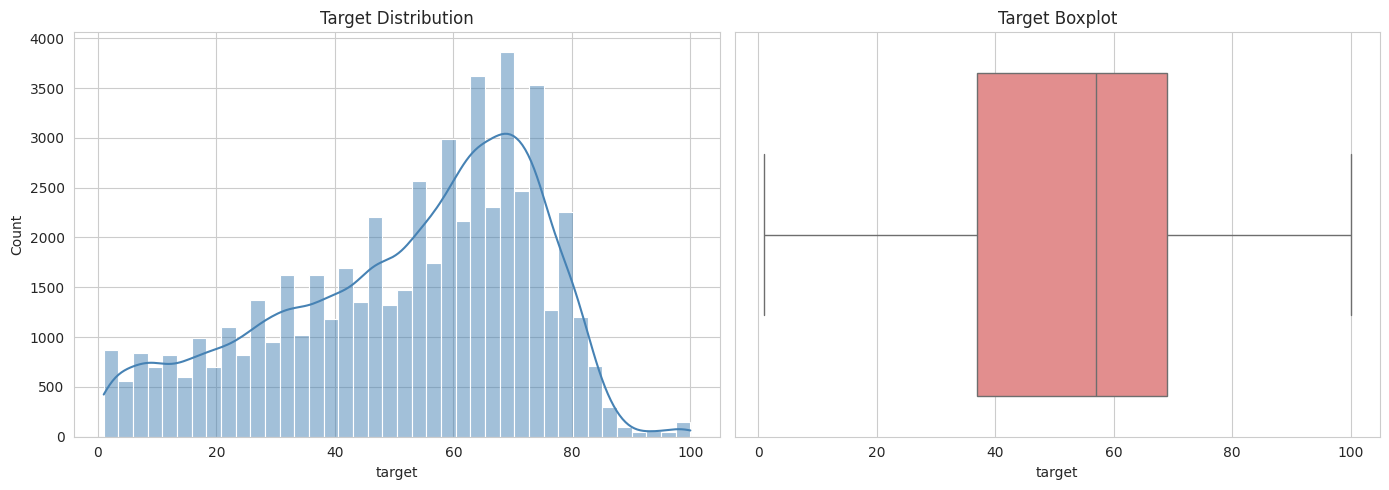

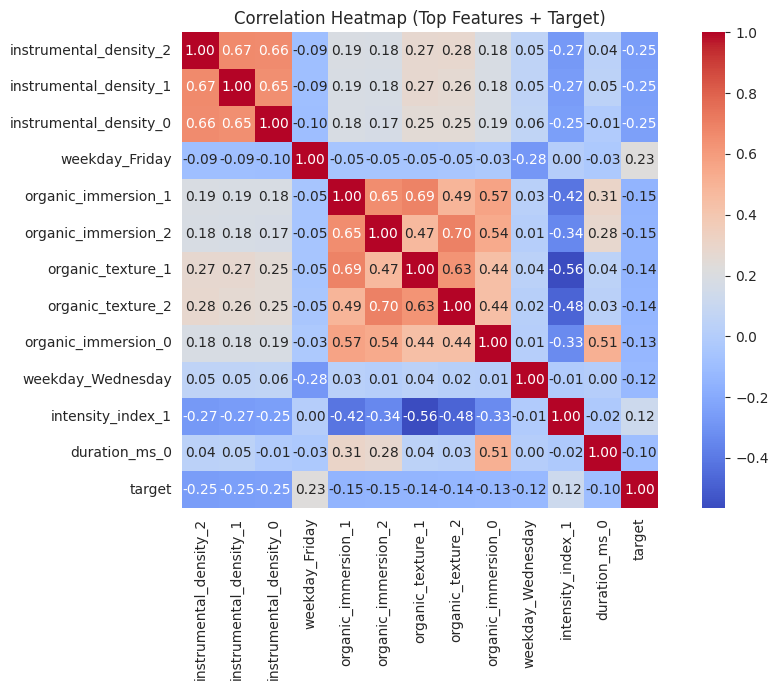

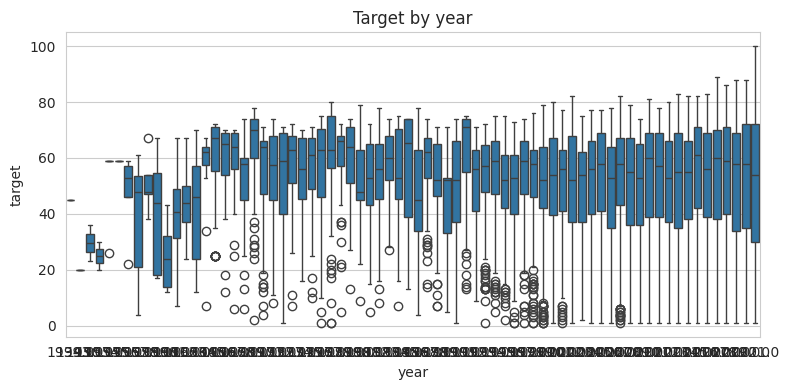

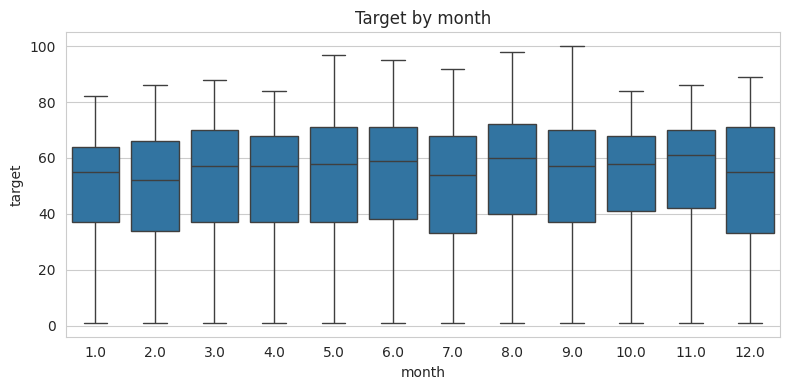

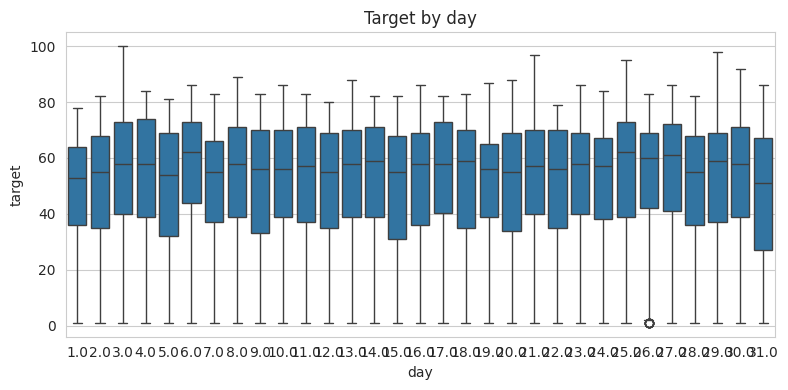

In [ ]:
sns.set_style('whitegrid')

# 1) Target distribution after preprocessing
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(df['target'], kde=True, bins=40, ax=axes[0], color='steelblue')
axes[0].set_title('Target Distribution')
axes[0].set_xlabel('target')

sns.boxplot(x=df['target'], ax=axes[1], color='lightcoral')
axes[1].set_title('Target Boxplot')
axes[1].set_xlabel('target')
plt.tight_layout()
plt.show()

# 2) Correlation heatmap of top numeric features by absolute relation with target
numeric_df = df.select_dtypes(include='number').copy()
if 'target' in numeric_df.columns:
    corr_with_target = numeric_df.corr()['target'].drop('target').abs().sort_values(ascending=False)
    top_features = corr_with_target.head(12).index.tolist()
    heatmap_cols = top_features + ['target']
    
    plt.figure(figsize=(10, 7))
    sns.heatmap(
        numeric_df[heatmap_cols].corr(),
        annot=True,
        fmt='.2f',
        cmap='coolwarm',
        square=True
    )
    plt.title('Correlation Heatmap (Top Features + Target)')
    plt.tight_layout()
    plt.show()

# 3) Quick look at engineered date features vs target
date_cols = [c for c in ['year', 'month', 'day'] if c in df.columns]
if date_cols:
    for col in date_cols:
        plt.figure(figsize=(8, 4))
        sns.boxplot(x=df[col], y=df['target'])
        plt.title(f'Target by {col}')
        plt.xlabel(col)
        plt.ylabel('target')
        plt.tight_layout()
        plt.show()

## Train/Test Split
Prepare feature matrix and holdout split.

In [44]:
X = df.drop(['target', 'id'], axis=1)
y = df['target']

# split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,  
    random_state=42 
)

## Train Model
Fit XGBoost regressor on training data.

In [45]:
model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

model.fit(X_train, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

## Validate Model
Check cross-validated RMSE performance.

In [46]:
# Evaluation: 5-fold cross-validated RMSE
cv = KFold(n_splits=5, shuffle=True, random_state=42)
cv_rmse_scores = -cross_val_score(
    model,
    X_train,
    y_train,
    scoring='neg_root_mean_squared_error',
    cv=cv,
    n_jobs=-1
)

print('CV RMSE mean:', cv_rmse_scores.mean().round(5))
print('CV RMSE std:', cv_rmse_scores.std().round(5))

CV RMSE mean: 12.71753
CV RMSE std: 0.10074


## Preprocess Test
Apply same transformations used for training features.

In [47]:
test_processed = test_df.copy()

test_processed = test_processed.drop(
    ['composition_label_0', 'composition_label_1', 'creator_collective', 'composition_label_2', 'track_identifier'],
    axis=1,
    errors='ignore'
 )
test_processed = test_processed.fillna(0)

week_test = pd.get_dummies(test_processed['weekday_of_release'], prefix='weekday', dtype=int)
test_processed = test_processed.drop('weekday_of_release', axis=1)
test_processed = test_processed.join(week_test)

season_test = pd.get_dummies(test_processed['season_of_release'], prefix='season', dtype=int)
test_processed = test_processed.drop('season_of_release', axis=1)
test_processed = test_processed.join(season_test)

lunar_test = pd.get_dummies(test_processed['lunar_phase'], prefix='lunar', dtype=int)
test_processed = test_processed.drop('lunar_phase', axis=1)
test_processed = test_processed.join(lunar_test)

test_processed['publication_timestamp'] = pd.to_datetime(
    test_processed['publication_timestamp'],
    errors='coerce'
 )
test_processed['year'] = test_processed['publication_timestamp'].dt.year
test_processed['month'] = test_processed['publication_timestamp'].dt.month
test_processed['day'] = test_processed['publication_timestamp'].dt.day
test_processed = test_processed.drop('publication_timestamp', axis=1)

# Keep only model features and align any missing one-hot columns
X_kaggle_test = test_processed.drop(['id'], axis=1, errors='ignore')
X_kaggle_test = X_kaggle_test.reindex(columns=X.columns, fill_value=0)

## Build Submission
Predict on test set and save submission CSV.

In [48]:
test_predictions = model.predict(X_kaggle_test)

submission = sample.copy()
submission['target'] = test_predictions
submission.to_csv('./data/submission.csv', index=False)

submission.head()

,id,target
0,25174,50.828732
1,38453,65.986366
2,29013,57.824810
3,57463,72.495636
4,51264,28.884312
